<a href="https://colab.research.google.com/github/EdwardDUt/hypercontractive-diffusion/blob/main/toy2d_hypercontractive_experiment_update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toy 2D Experiment: Hypercontractive-Time Complexity Collapse

This notebook visualizes the score-complexity collapse predicted by the hypercontractive-time framework.

We use a 2D Gaussian-mixture data distribution and evolve it under the variance-preserving Ornstein--Uhlenbeck forward diffusion
$$
dX_t = -\beta(t) X_t\,dt + \sqrt{2\beta(t)}\,dB_t,
$$
with $\Sigma = I$.

The notebook produces:
- schedule and cumulative-noise curves $\beta(t)$ and $\tau(t)$,
- density / score / residual-score visualizations at several times,
- complexity curves versus physical time $t$,
- complexity curves versus hypercontractive time $\tau(t)$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path

plt.rcParams["figure.dpi"] = 140
RESULTS_DIR = Path("/mnt/data/toy2d_notebook_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data distribution

We use an eight-component Gaussian ring mixture:
$$
p_0(x) = \frac{1}{K}\sum_{k=1}^K \mathcal N(x; \mu_k, \sigma_0^2 I).
$$

Under the OU forward diffusion, each component remains Gaussian:
$$
X_t \mid Z=k \sim \mathcal{N} \bigl(e^{-\tau(t)}\mu_k,\; v_t I\bigr),
\qquad
v_t = 1 - e^{-2\tau(t)} + e^{-2\tau(t)}\sigma_0^2.
$$

This makes the score field analytically tractable.

In [ ]:
# Gaussian-mixture setup
K = 8
radius = 2.5
sigma0 = 0.18

angles = np.linspace(0, 2*np.pi, K, endpoint=False)
means0 = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
weights = np.ones(K) / K
I2 = np.eye(2)

@dataclass
class Schedule:
    name: str
    beta_fn: callable
    tau_fn: callable

def make_linear(beta0=0.1, beta1=12.0, T=1.0):
    def beta(t):
        t = np.asarray(t)
        return beta0 + (beta1 - beta0) * t / T
    def tau(t):
        t = np.asarray(t)
        return beta0 * t + 0.5 * (beta1 - beta0) * (t**2) / T
    return Schedule("linear", beta, tau)

def make_front_loaded(beta0=0.1, beta1=12.0, sharpness=5.0):
    # increases quickly near t=0 then saturates
    Z = 1.0 - np.exp(-sharpness)
    def beta(t):
        t = np.asarray(t)
        return beta0 + (beta1 - beta0) * np.exp(-sharpness * t)
    def tau(t):
        t = np.asarray(t)
        return beta0 * t + (beta1 - beta0) * (1.0 - np.exp(-sharpness * t)) / sharpness
    return Schedule("front_loaded", beta, tau)

def make_cosine(beta_min=0.2, beta_max=8.0):
    def beta(t):
        t = np.asarray(t)
        return beta_min + 0.5*(beta_max-beta_min)*(1 - np.cos(np.pi*t))
    def tau(t):
        t = np.asarray(t)
        return beta_min*t + 0.5*(beta_max-beta_min)*(t - np.sin(np.pi*t)/np.pi)
    return Schedule("cosine", beta, tau)

schedules = [
    make_linear(),
    make_cosine(),
    make_front_loaded(),
]

## 2. Exact density and score under the forward diffusion

In [ ]:
def component_stats(tau):
    a = np.exp(-tau)
    var = 1.0 - np.exp(-2*tau) + np.exp(-2*tau) * sigma0**2
    means_t = a * means0
    return means_t, var

def gaussian_pdf_batch(X, mean, var):
    # X shape (N,2), mean shape (2,)
    diff = X - mean[None, :]
    quad = np.sum(diff * diff, axis=1) / var
    norm = 1.0 / (2*np.pi*var)
    return norm * np.exp(-0.5 * quad)

def mixture_density_and_score(X, tau):
    means_t, var = component_stats(tau)
    N = X.shape[0]
    comp_pdfs = np.stack([gaussian_pdf_batch(X, m, var) for m in means_t], axis=1)  # (N,K)
    weighted = comp_pdfs * weights[None, :]
    density = weighted.sum(axis=1) + 1e-300

    # score of each component: -(x - mu)/var
    comp_scores = np.stack([-(X - m[None, :]) / var for m in means_t], axis=1)  # (N,K,2)
    posterior = weighted / density[:, None]
    score = np.sum(posterior[:, :, None] * comp_scores, axis=1)
    return density, score

def residual_score(score, X):
    return score + X  # because Sigma = I

def residual_complexity_mc(tau, n_samples=20000, seed=0):
    rng = np.random.default_rng(seed)
    means_t, var = component_stats(tau)
    comps = rng.choice(K, size=n_samples, p=weights)
    X = means_t[comps] + np.sqrt(var) * rng.standard_normal((n_samples, 2))
    _, score = mixture_density_and_score(X, tau)
    resid = residual_score(score, X)
    return np.mean(np.sum(resid**2, axis=1))

## 3. Schedule plots

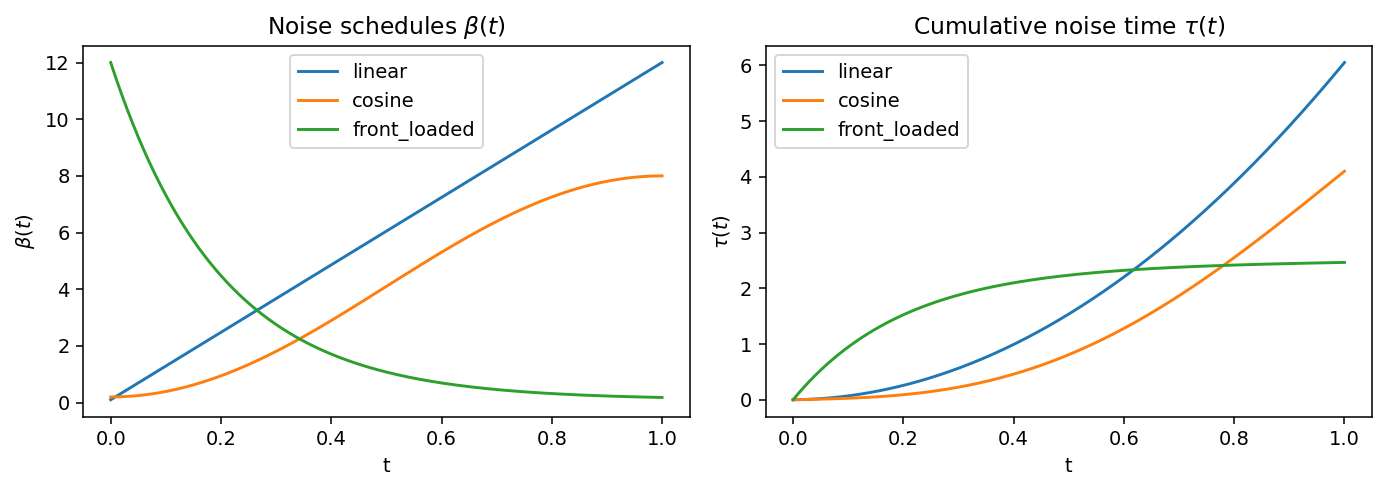

In [ ]:
ts = np.linspace(0, 1, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for sched in schedules:
    axes[0].plot(ts, sched.beta_fn(ts), label=sched.name)
    axes[1].plot(ts, sched.tau_fn(ts), label=sched.name)
axes[0].set_title(r"Noise schedules $\beta(t)$")
axes[1].set_title(r"Cumulative noise time $\tau(t)$")
for ax in axes:
    ax.set_xlabel("t")
    ax.legend()
axes[0].set_ylabel(r"$\beta(t)$")
axes[1].set_ylabel(r"$\tau(t)$")
plt.tight_layout()
plt.show()
fig.savefig(RESULTS_DIR / "schedules.png", bbox_inches="tight")

## 4. Density / score / residual-score visualization

We choose one schedule and visualize:
- the density $p_t$,
- the score field $\nabla \log p_t$,
- the residual score field $u_t = \nabla \log p_t + x$,

at three representative times.

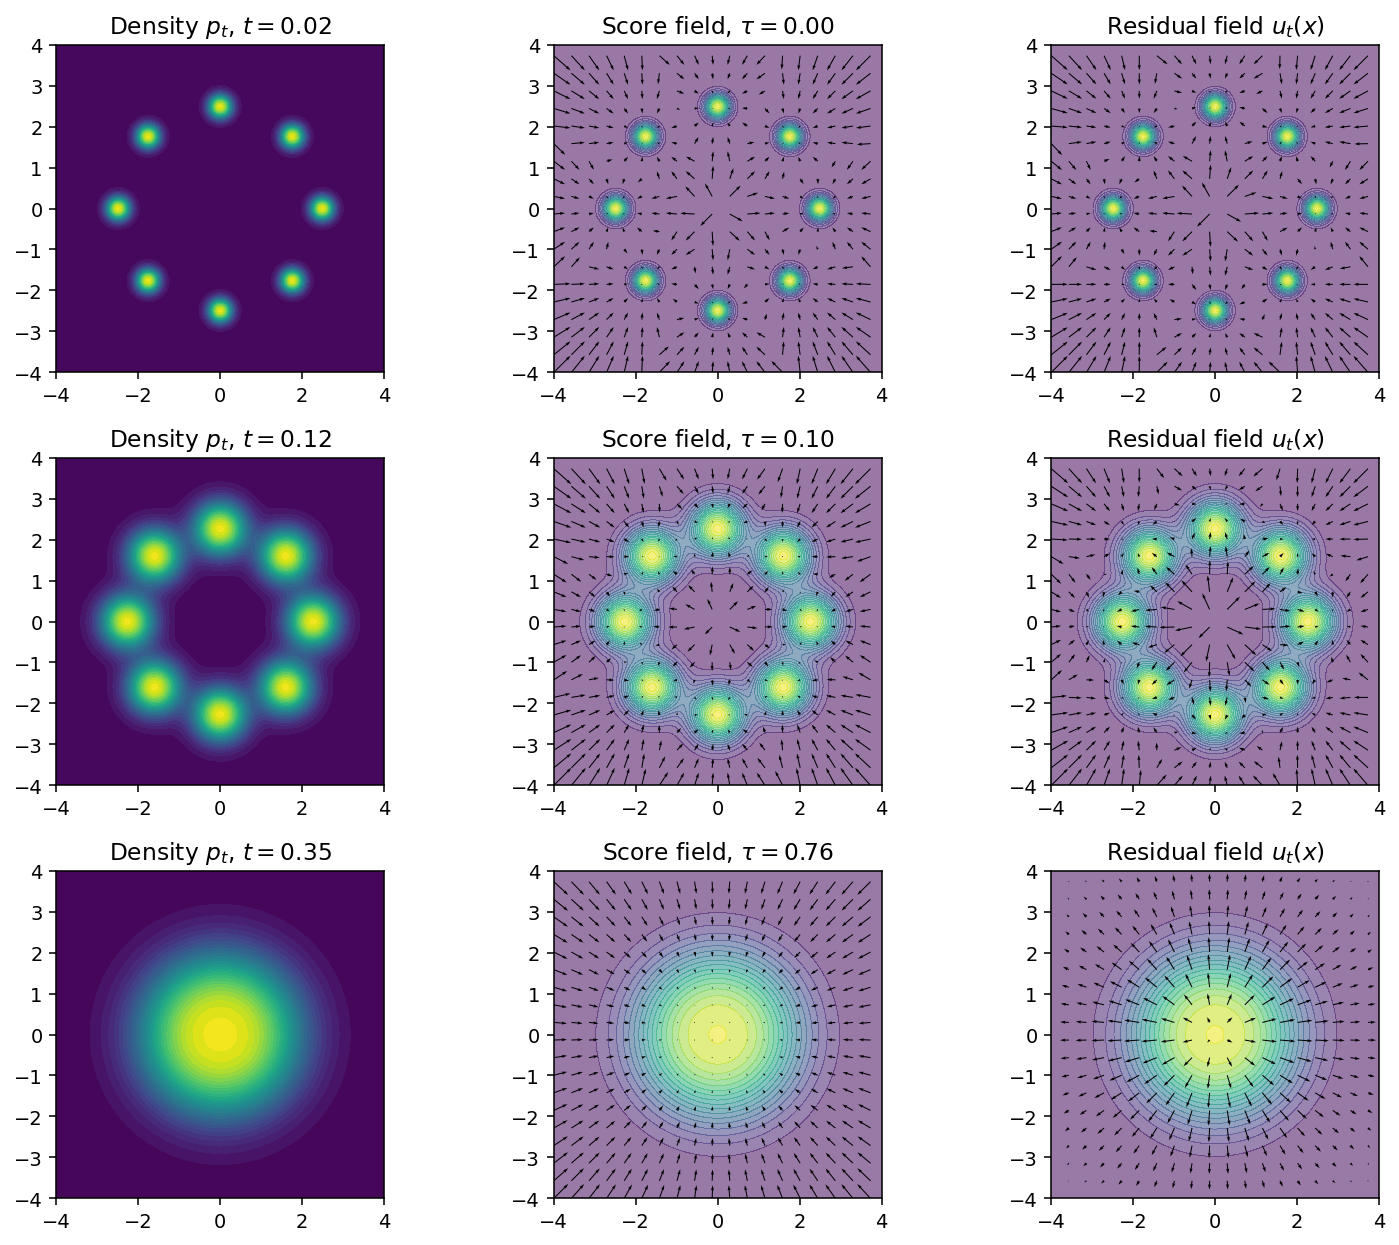

In [ ]:
viz_schedule = schedules[0]  # linear
times_viz = [0.02, 0.12, 0.35]

grid_lim = 4.0
n_grid = 150
x1 = np.linspace(-grid_lim, grid_lim, n_grid)
x2 = np.linspace(-grid_lim, grid_lim, n_grid)
XX, YY = np.meshgrid(x1, x2)
grid = np.stack([XX.ravel(), YY.ravel()], axis=1)

fig, axes = plt.subplots(len(times_viz), 3, figsize=(11, 9))
for row, t in enumerate(times_viz):
    tau = float(viz_schedule.tau_fn(t))
    dens, score = mixture_density_and_score(grid, tau)
    resid = residual_score(score, grid)

    dens_img = dens.reshape(n_grid, n_grid)
    score_img = score.reshape(n_grid, n_grid, 2)
    resid_img = resid.reshape(n_grid, n_grid, 2)

    stride = 8
    xs = XX[::stride, ::stride]
    ys = YY[::stride, ::stride]

    axes[row, 0].contourf(XX, YY, dens_img, levels=30)
    axes[row, 0].set_title(rf"Density $p_t$, $t={t:.2f}$")
    axes[row, 0].set_aspect("equal")

    axes[row, 1].contourf(XX, YY, dens_img, levels=20, alpha=0.55)
    axes[row, 1].quiver(xs, ys,
                        score_img[::stride, ::stride, 0],
                        score_img[::stride, ::stride, 1])
    axes[row, 1].set_title(rf"Score field, $\tau={tau:.2f}$")
    axes[row, 1].set_aspect("equal")

    axes[row, 2].contourf(XX, YY, dens_img, levels=20, alpha=0.55)
    axes[row, 2].quiver(xs, ys,
                        resid_img[::stride, ::stride, 0],
                        resid_img[::stride, ::stride, 1])
    axes[row, 2].set_title(r"Residual field $u_t(x)$")
    axes[row, 2].set_aspect("equal")

for ax in axes.ravel():
    ax.set_xlim(-grid_lim, grid_lim)
    ax.set_ylim(-grid_lim, grid_lim)
plt.tight_layout()
plt.show()
fig.savefig(RESULTS_DIR / "toy_density_score_residual.png", bbox_inches="tight")

## 5. Complexity curves versus physical time and hypercontractive time

We compute
$$
\mathcal C(t) = \mathbb E_{x\sim p_t}\|u_t(x)\|^2
$$
for each schedule, then compare:
- $\mathcal C(t)$ vs. physical time $t$,
- $\mathcal C(t)$ vs. cumulative noise time $\tau(t)$.

If the theory is correct, the second plot should exhibit much stronger alignment across schedules.

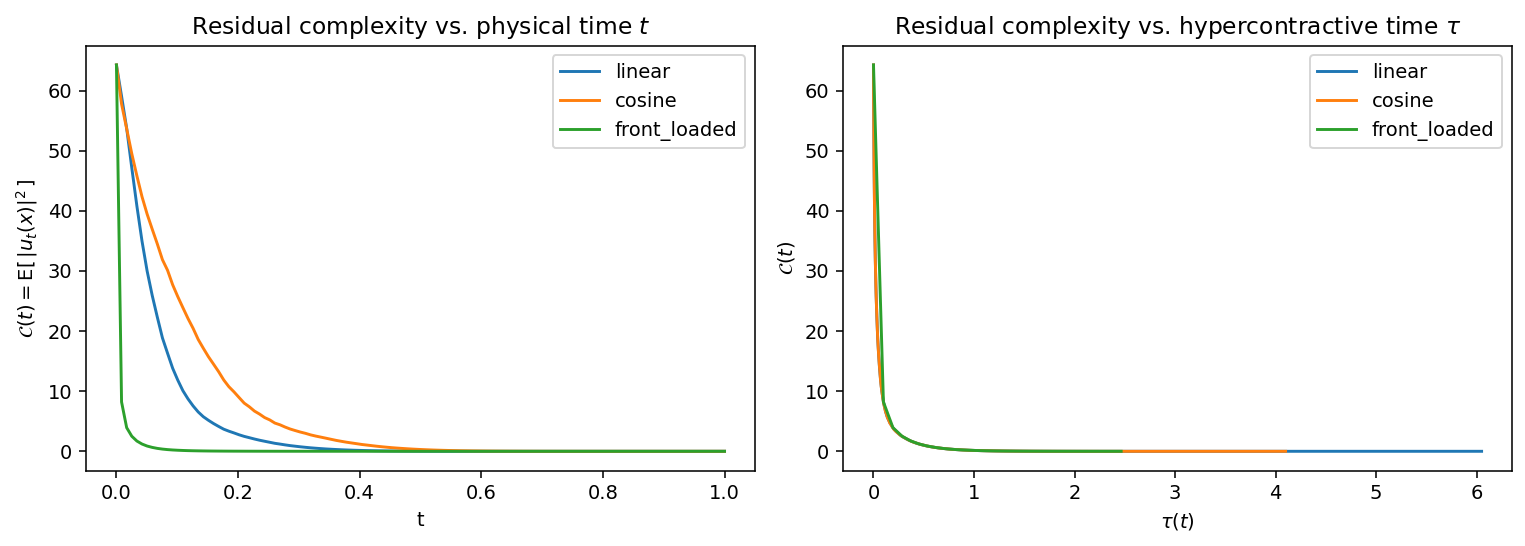

In [ ]:
ts_eval = np.linspace(0.0, 1.0, 120)

complexities = {}
taus = {}
for sched in schedules:
    comp = []
    tau_vals = sched.tau_fn(ts_eval)
    for idx, tau in enumerate(tau_vals):
        comp.append(residual_complexity_mc(float(tau), n_samples=12000, seed=idx))
    complexities[sched.name] = np.array(comp)
    taus[sched.name] = np.array(tau_vals)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for sched in schedules:
    name = sched.name
    axes[0].plot(ts_eval, complexities[name], label=name)
    axes[1].plot(taus[name], complexities[name], label=name)

axes[0].set_title(r"Residual complexity vs. physical time $t$")
axes[1].set_title(r"Residual complexity vs. hypercontractive time $\tau$")
axes[0].set_xlabel("t")
axes[1].set_xlabel(r"$\tau(t)$")
axes[0].set_ylabel(r"$\mathcal{C}(t)=\mathrm{E}[\,|u_t(x)|^2\,]$")
axes[1].set_ylabel(r"$\mathcal{C}(t)$")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Optional: save the raw curves

In [ ]:
import csv

csv_path = RESULTS_DIR / "toy2d_complexity_curves.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["schedule", "t", "tau", "complexity"])
    for sched in schedules:
        name = sched.name
        for t, tau, c in zip(ts_eval, taus[name], complexities[name]):
            writer.writerow([name, float(t), float(tau), float(c)])

print(f"Saved outputs to: {RESULTS_DIR}")
print(f"CSV: {csv_path}")

Saved outputs to: /mnt/data/toy2d_notebook_results
CSV: /mnt/data/toy2d_notebook_results/toy2d_complexity_curves.csv
